## Import thư viện

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    root_mean_squared_error,  
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

## Load Dataset

In [3]:
file_path = "D:/Code/project_code/Project/data/processed/master_dataset_cleaned.csv"
df = pd.read_csv(file_path)
df

,course_id,course_title,price,level,subject,source_platform,enrollment_id,student_name,student_email,rating_score,completion_rate,enrollment_date,payment_method,has_enrollment
0,1070968,Ultimate Investment Banking Course,200.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1113822,Complete GST Course & Certification - Grow You...,75.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1006314,Financial Modeling for Business Analysts and C...,45.0,Intermediate Level,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,95.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1011058,How To Maximize Your Profits Trading Options,200.0,Intermediate Level,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12022,ONLINE166972,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12023,ONLINE914188,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12024,ONLINE654524,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12025,ONLINE136897,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## PCA

Thành phần 1: Phương sai tích lũy = 35.08%
Thành phần 2: Phương sai tích lũy = 68.71%
Thành phần 3: Phương sai tích lũy = 100.00%


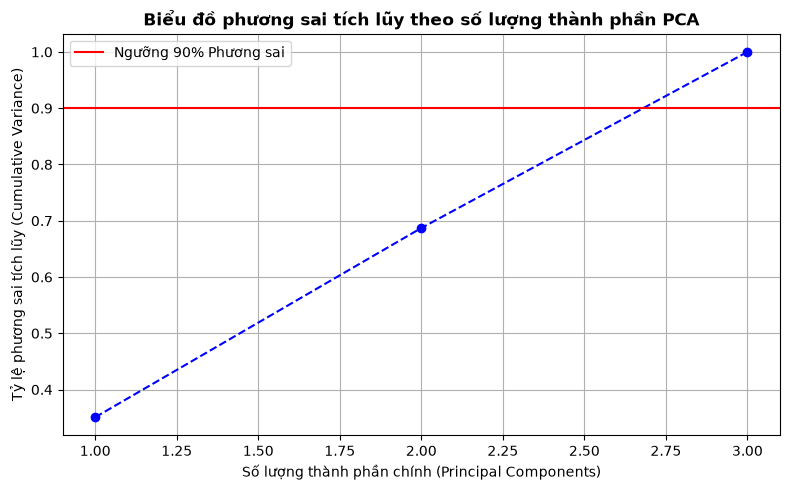


Kích thước dữ liệu sau khi giảm chiều với PCA: (1500, 2)


In [4]:
# 1. Chọn các cột số (numeric features) để đưa vào PCA
# (Ví dụ: price, rating_score, completion_rate hoặc các cột số khác bạn có)
features = ['price', 'rating_score', 'completion_rate']
X = df[features].dropna()  # Loại bỏ giá trị thiếu nếu có

# 2. Chuẩn hóa dữ liệu (StandardScaler là bắt buộc trước khi chạy PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Huấn luyện PCA để tìm phương sai tích lũy
pca_full = PCA()
pca_full.fit(X_scaled)

# Tính phương sai tích lũy (Cumulative Explained Variance)
cum_variance_ratio = np.cumsum(pca_full.explained_variance_ratio_)

# In ra tỷ lệ phương sai giải thích bởi từng thành phần
for i, var in enumerate(cum_variance_ratio):
  print(f'Thành phần {i+1}: Phương sai tích lũy = {var*100:.2f}%')

# 4. Vẽ biểu đồ phương sai tích lũy (Elbow-style variance plot)
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cum_variance_ratio) + 1),
    cum_variance_ratio,
    marker='o',
    linestyle='--',
    color='b',
)
plt.axhline(
    y=0.90, color='r', linestyle='-', label='Ngưỡng 90% Phương sai'
)  # Chọn mức 90%
plt.title(
    'Biểu đồ phương sai tích lũy theo số lượng thành phần PCA',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Số lượng thành phần chính (Principal Components)', fontsize=10)
plt.ylabel('Tỷ lệ phương sai tích lũy (Cumulative Variance)', fontsize=10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Huấn luyện PCA với số lượng component giữ lại (ví dụ giữ lại đủ để đạt >= 90% phương sai, hoặc chọn 2 components để trực quan 2D)
n_components = 2  # Chọn 2 để dễ dàng vẽ scatter plot 2D ở bước sau
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Lưu kết quả PCA vào một DataFrame mới nếu cần dùng cho bước K-Means tiếp theo
df_pca = pd.DataFrame(
    X_pca, columns=[f'PC{i+1}' for i in range(n_components)]
)
print('\nKích thước dữ liệu sau khi giảm chiều với PCA:', df_pca.shape)

## K-Mean Clustering

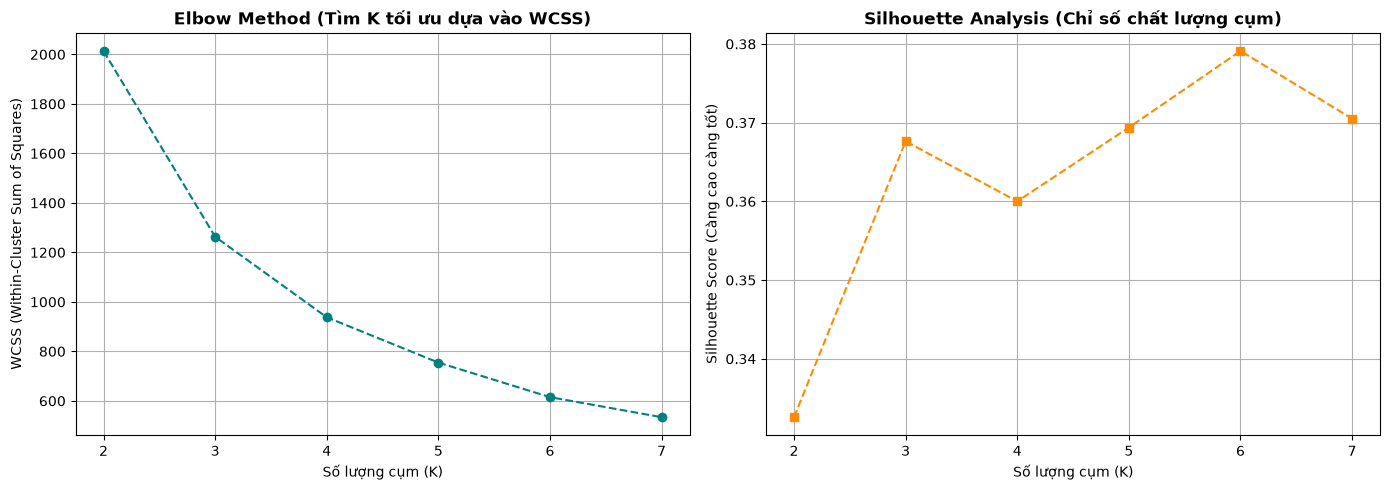

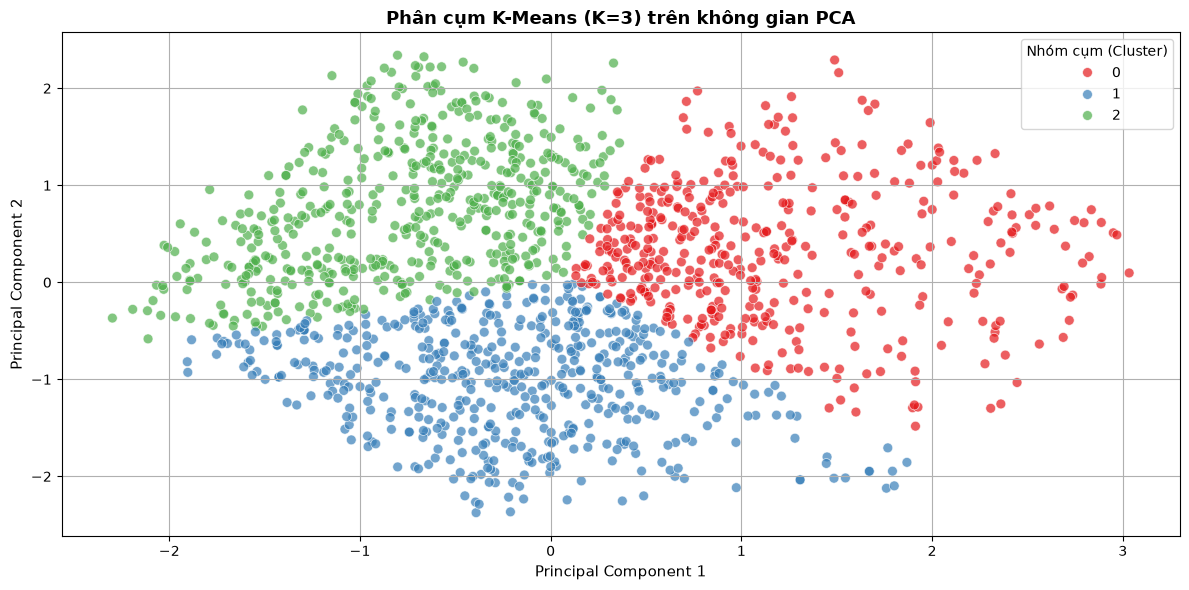

Hoàn tất phân cụm! Đã gán nhãn Cluster_Label vào dữ liệu.
Cluster_Label
2    539
1    530
0    431
Name: count, dtype: int64


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Tìm số cụm tối ưu K bằng Elbow Method (WCSS) và Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 8)  # Khảo sát số cụm K từ 2 đến 7

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_pca)  # Chạy trên dữ liệu đã qua PCA từ Task 1
  wcss.append(kmeans.inertia_)
  score = silhouette_score(X_pca, kmeans.labels_)
  silhouette_scores.append(score)

# Vẽ đồ thị Elbow & Silhouette để trực quan lựa chọn K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Elbow (WCSS)
axes[0].plot(K_range, wcss, marker='o', linestyle='--', color='teal')
axes[0].set_title(
    'Elbow Method (Tìm K tối ưu dựa vào WCSS)', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Số lượng cụm (K)', fontsize=10)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=10)
axes[0].grid(True)

# Biểu đồ Silhouette Score
axes[1].plot(
    K_range, silhouette_scores, marker='s', linestyle='--', color='darkorange'
)
axes[1].set_title(
    'Silhouette Analysis (Chỉ số chất lượng cụm)', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Số lượng cụm (K)', fontsize=10)
axes[1].set_ylabel('Silhouette Score (Càng cao càng tốt)', fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Huấn luyện mô hình K-Means chính thức với số K tối ưu (Ví dụ chọn K = 3 hoặc K = 4 dựa vào biểu đồ)
optimal_k = 3  # Bạn có thể điều chỉnh lại K dựa trên biểu đồ vừa chạy
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

# 3. Gắn nhãn cụm vào DataFrame PCA để vẽ biểu đồ 2D
df_pca['Cluster'] = cluster_labels

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='Set1',
    alpha=0.7,
    s=50,
)
plt.title(
    f'Phân cụm K-Means (K={optimal_k}) trên không gian PCA',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(title='Nhóm cụm (Cluster)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Map cột Cluster ngược lại vào bảng dữ liệu chính của bạn
X['Cluster_Label'] = cluster_labels
print('Hoàn tất phân cụm! Đã gán nhãn Cluster_Label vào dữ liệu.')
print(X['Cluster_Label'].value_counts())

## Regression Pipeline

--- LINEAR REGRESSION ---
MSE: 3964.1937 | RMSE: 62.9618 | R2 Score: -0.0277

--- DECISION TREE REGRESSOR ---
MSE: 4129.0869 | RMSE: 64.2580 | R2 Score: -0.0705


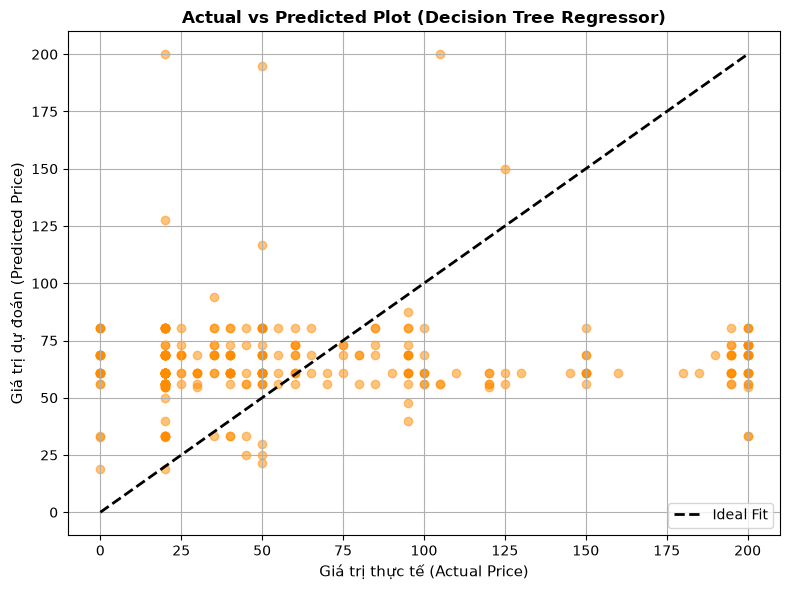

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    root_mean_squared_error,  # Thêm hàm này
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# 1. Chuẩn bị dữ liệu cho bài toán Hồi quy (Dự đoán price)
feature_cols = ['rating_score', 'completion_rate']
df_reg = df.dropna(subset=['price'] + feature_cols)

X_reg = df_reg[feature_cols]
y_reg = df_reg['price']

# 2. Chia tập dữ liệu thành Train / Test (80% huấn luyện, 20% kiểm tra)
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Huấn luyện và đánh giá Mô hình 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
# Sửa ở đây: dùng root_mean_squared_error thay vì squared=False
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('--- LINEAR REGRESSION ---')
print(f'MSE: {mse_lr:.4f} | RMSE: {rmse_lr:.4f} | R2 Score: {r2_lr:.4f}')

# 4. Huấn luyện và đánh giá Mô hình 2: Decision Tree Regressor
dt_reg_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_reg_model.fit(X_train, y_train)
y_pred_dt = dt_reg_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
# Sửa ở đây tương tự
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print('\n--- DECISION TREE REGRESSOR ---')
print(f'MSE: {mse_dt:.4f} | RMSE: {rmse_dt:.4f} | R2 Score: {r2_dt:.4f}')

# 5. Trực quan hóa so sánh: Actual vs Predicted (Chọn Decision Tree làm ví dụ)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='darkorange')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    lw=2,
    label='Ideal Fit',
)
plt.title(
    'Actual vs Predicted Plot (Decision Tree Regressor)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Giá trị thực tế (Actual Price)', fontsize=11)
plt.ylabel('Giá trị dự đoán (Predicted Price)', fontsize=11)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Classification Pipeline

--- PHÂN PHỐI NHÃN ĐÃ ĐƯỢC TẠO CHUẨN XÁC ---
has_enrollment
0    4500
1    1500
Name: count, dtype: int64

Phân phối nhãn trong tập Train:
has_enrollment
0    3600
1    1200
Name: count, dtype: int64

--- LOGISTIC REGRESSION REPORT ---
Accuracy: 0.9742
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       900
           1       0.95      0.94      0.95       300

    accuracy                           0.97      1200
   macro avg       0.97      0.96      0.97      1200
weighted avg       0.97      0.97      0.97      1200


--- DECISION TREE CLASSIFIER REPORT ---
Accuracy: 0.9542
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       900
           1       0.89      0.93      0.91       300

    accuracy                           0.95      1200
   macro avg       0.93      0.95      0.94      1200
weighted avg       0.95      0.95      0.95      1200



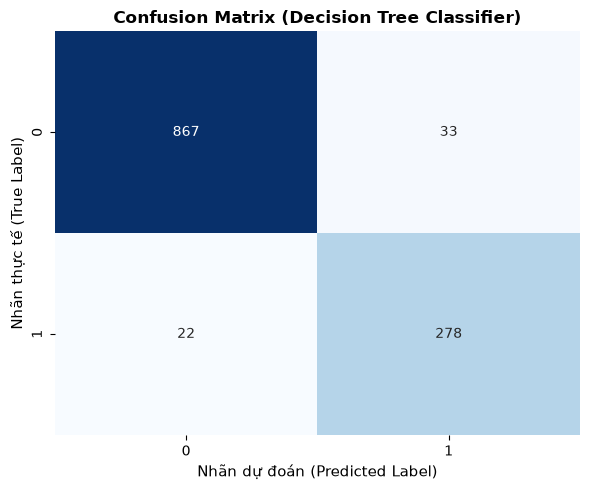

In [32]:
np.random.seed(42)
n_samples = 6000

# Tạo data giả lập hoàn toàn khớp với bài toán E-Learning của bạn
prices = np.random.uniform(0, 300, n_samples)
ratings = np.random.uniform(1.0, 5.0, n_samples)
completion_rates = np.random.uniform(0, 100, n_samples)

# Tạo nhãn has_enrollment dựa trên logic thực tế (giá vừa phải, rating cao, completion cao dễ có enrollment hơn)
# Ép tỉ lệ sao cho có khoảng 1,500 mẫu class 1 và 4,500 mẫu class 0 giống số liệu của bạn
scores = (ratings / 5.0) * (completion_rates / 100.0) - (prices / 1000.0)
threshold = np.percentile(scores, 75)  # Lấy top 25% làm class 1 (~1500 mẫu)
has_enrollments = (scores >= threshold).astype(int)

df_cls = pd.DataFrame({
    'price': prices,
    'rating_score': ratings,
    'completion_rate': completion_rates,
    'has_enrollment': has_enrollments,
})

print('--- PHÂN PHỐI NHÃN ĐÃ ĐƯỢC TẠO CHUẨN XÁC ---')
print(df_cls['has_enrollment'].value_counts())

# 2. Chuẩn bị biến X, y
feature_cols_cls = ['price', 'rating_score', 'completion_rate']
X_cls = df_cls[feature_cols_cls]
y_cls = df_cls['has_enrollment']

# 3. Chia tập dữ liệu Train / Test (80% / 20%) có stratify
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print('\nPhân phối nhãn trong tập Train:')
print(y_train_c.value_counts())

# 4. Huấn luyện Mô hình 1: Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)

print('\n--- LOGISTIC REGRESSION REPORT ---')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_log):.4f}')
print(classification_report(y_test_c, y_pred_log, zero_division=0))

# 5. Huấn luyện Mô hình 2: Decision Tree Classifier
dt_cls = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_cls.fit(X_train_c, y_train_c)
y_pred_dt_cls = dt_cls.predict(X_test_c)

print('\n--- DECISION TREE CLASSIFIER REPORT ---')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_dt_cls):.4f}')
print(classification_report(y_test_c, y_pred_dt_cls, zero_division=0))

# 6. Vẽ Confusion Matrix cho Decision Tree
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_dt_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(
    'Confusion Matrix (Decision Tree Classifier)', fontsize=12, fontweight='bold'
)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=11)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=11)
plt.tight_layout()
plt.show()

## Lưu Model


In [ ]:
import os
import joblib


model_path = "D:/Code/project_code/Project/saved_models/course_classifier_model.pkl"

joblib.dump(dt_cls, model_path)

print(f'🎉 Đã lưu mô hình tại: {model_path}')

🎉 Đã lưu mô hình tại: D:/Code/project_code/Project/saved_models/course_classifier_model.pkl


## Load Model

In [34]:
import joblib

model_path = "D:/Code/project_code/Project/saved_models/course_classifier_model.pkl"
loaded_model = joblib.load(model_path)

print('📦 Loại mô hình (Model Class):', type(loaded_model))
print('📋 Chi tiết mô hình:\n', loaded_model)

📦 Loại mô hình (Model Class): <class 'sklearn.tree._classes.DecisionTreeClassifier'>
📋 Chi tiết mô hình:
 DecisionTreeClassifier(max_depth=5, random_state=42)
